# Predicting Student Exam Scores Using Regression Models

## Mission
This project is trying to predict how well a student will score on their exam based on things like how many hours they study, their attendance, whether their parents are involved and other factors. the idea is that if we can predict low scores early, teachers can step in and help those students before it is too late

The dataset that was used is the **Student Performance Factors** dataset from Kaggle, it has about 6607 rows and 20 columns covering a mix of numeric and categorical features like study hours, sleep, motivation level, internet access, and parental education, the target column we are trying to predict is ```Exam Score```
Dataset source: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
Models being used: linear regression, decision tree regressor, and random forest regressor, all from scikit-learn



## 1. importing the libraries i need

In [56]:
# importing the tools i need for splitting data, scaling, and the models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

## 2. loading the dataset

In [57]:
# loadingthe csv
df = pd.read_csv('StudentPerformanceFactors.csv')

print('shape of the dataset:', df.shape)
print('columns:', list(df.columns))
df.head()

shape of the dataset: (6607, 20)
columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 3. exploring the data

- what the data looks like
- how many missing values there are
- what types of columns it has

In [58]:
# getting a quick summary of the data types and non-null counts
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [59]:
# checking for missing values in all columns
missing = df.isnull().sum()
print('missing values per column:')
print(missing[missing > 0] if missing.any() else 'no missing values found')

missing values per column:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


In [60]:
# here  I will be separating columns into categorical and numeric so I know what needs encoding later
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('categorical columns:', cat_cols)
print('numeric columns:', num_cols)
print('\n')
print('unique values in each categorical column:')
for col in cat_cols:
    print(col, ':', df[col].unique())

categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
numeric columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


unique values in each categorical column:
Parental_Involvement : <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Access_to_Resources : <StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
Extracurricular_Activities : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Motivation_Level : <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Internet_Access : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Family_Income : <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Teacher_Quality : <StringArray>
['Medium', 'High',

### looking at the distribution of exam scores

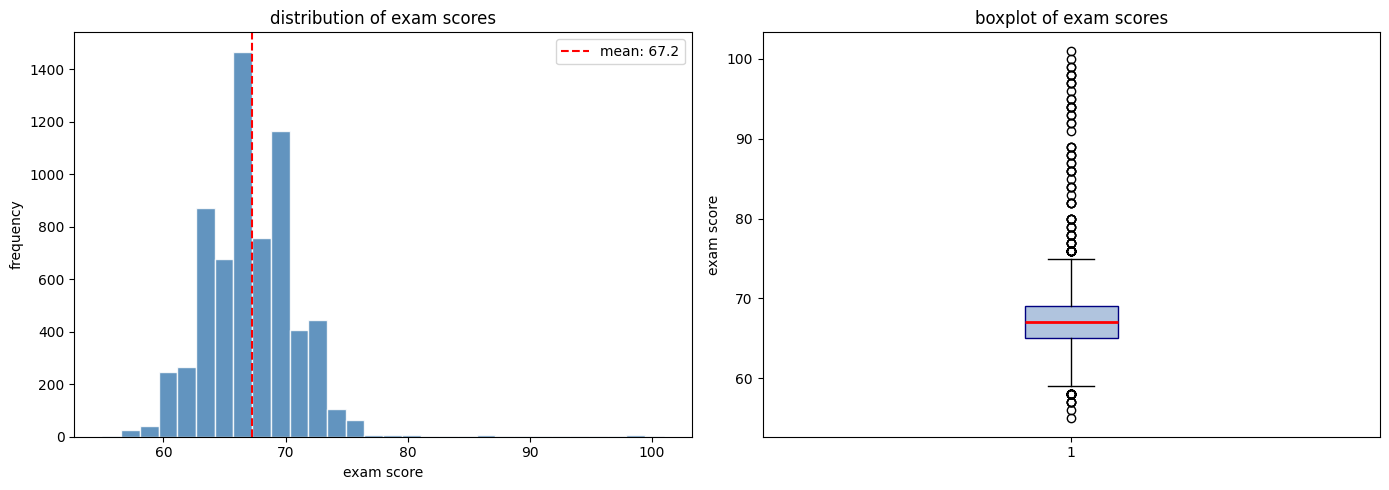



mean exam score: 67.24
standard deviation: 3.89
min: 55   max: 101


In [61]:
# a plot of a histogram and a boxplot side by side to understand how exam scores are spread out
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Exam_Score'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('distribution of exam scores')
axes[0].set_xlabel('exam score')
axes[0].set_ylabel('frequency')
axes[0].axvline(df['Exam_Score'].mean(), color='red', linestyle='--', label='mean: ' + str(round(df['Exam_Score'].mean(), 1)))
axes[0].legend()
axes[1].boxplot(df['Exam_Score'], patch_artist=True, boxprops=dict(facecolor='lightsteelblue', color='navy'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('boxplot of exam scores')
axes[1].set_ylabel('exam score')
plt.tight_layout()
plt.show()
print('\n')
print('mean exam score:', round(df['Exam_Score'].mean(), 2))
print('standard deviation:', round(df['Exam_Score'].std(), 2))
print('min:', df['Exam_Score'].min(), '  max:', df['Exam_Score'].max())

### correlation heatmap for numeric features

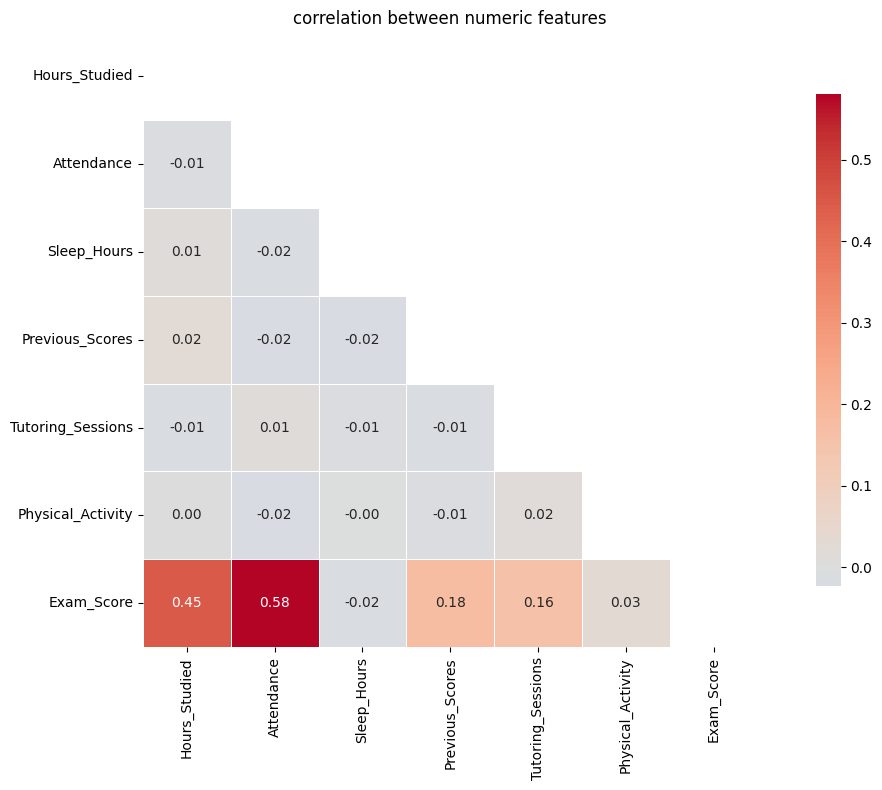

In [62]:
plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('correlation between numeric features')
plt.tight_layout()
plt.show()

## 4. feature engineering

In [63]:
# I will be deciding which columns to keep and which to drop, and how to convert categorical ones to numbers
df_eng = df.copy()

# temporarily encoding the categorical columns so I can measure their correlation with exam score
df_temp = df_eng.copy()
for col in cat_cols:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))

correlations = df_temp.corr()['Exam_Score'].drop('Exam_Score').sort_values(key=abs, ascending=False)
print('feature correlations with exam score sorted by strength:')
print(correlations.round(3))

feature correlations with exam score sorted by strength:
Attendance                    0.581
Hours_Studied                 0.445
Previous_Scores               0.175
Tutoring_Sessions             0.157
Peer_Influence                0.100
Parental_Involvement         -0.094
Access_to_Resources          -0.091
Learning_Disabilities        -0.085
Distance_from_Home            0.084
Extracurricular_Activities    0.064
Teacher_Quality              -0.062
Internet_Access               0.051
Parental_Education_Level      0.040
Physical_Activity             0.028
Family_Income                -0.026
Sleep_Hours                  -0.017
Motivation_Level             -0.015
School_Type                  -0.009
Gender                       -0.002
Name: Exam_Score, dtype: float64


In [64]:
# now im going to drop columns that have almost no correlation with the target since they just add noise
# 0.02 will be the threshold meaning anything below that will be removed
low_corr_threshold = 0.02
low_corr_features = correlations[abs(correlations) < low_corr_threshold].index.tolist()
print('columns being dropped because their correlation \nis below', low_corr_threshold, ':', low_corr_features)

if low_corr_features:
    df_eng.drop(columns=low_corr_features, inplace=True, errors='ignore')
else:
    print('no columns dropped, all features have some correlation')

print('remaining shape:', df_eng.shape)

columns being dropped because their correlation 
is below 0.02 : ['Sleep_Hours', 'Motivation_Level', 'School_Type', 'Gender']
remaining shape: (6607, 16)


In [65]:
# converting categorical columns to numbers
# for columns that have a natural order like low medium high we use a manual mapping
# for columns that are just labels with no order we use label encoder

cat_remaining = df_eng.select_dtypes(include='object').columns.tolist()
print('categorical columns still needing to be encoded:', cat_remaining)

# these columns have a clear ranking so we map them to 0 1 2 to preserve that order
ordinal_maps = {
    'Parental_Involvement':     {'Low': 0, 'Medium': 1, 'High': 2},
    'Access_to_Resources':      {'Low': 0, 'Medium': 1, 'High': 2},
    'Motivation_Level':         {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income':            {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality':          {'Low': 0, 'Medium': 1, 'High': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distance_from_Home':       {'Near': 0, 'Moderate': 1, 'Far': 2},
    'Peer_Influence':           {'Negative': 0, 'Neutral': 1, 'Positive': 2},
}

# for anything that is not in the ordinal map above we just use label encoder
label_encode_cols = [col for col in cat_remaining if col not in ordinal_maps]

le = LabelEncoder()
for col in label_encode_cols:
    df_eng[col] = le.fit_transform(df_eng[col].astype(str))
    print('label encoded:', col)

for col, mapping in ordinal_maps.items():
    if col in df_eng.columns:
        df_eng[col] = df_eng[col].map(mapping)
        print('ordinal encoded:', col)

print()
print('data types after encoding:')
print(df_eng.dtypes)

categorical columns still needing to be encoded: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home']
label encoded: Extracurricular_Activities
label encoded: Internet_Access
label encoded: Learning_Disabilities
ordinal encoded: Parental_Involvement
ordinal encoded: Access_to_Resources
ordinal encoded: Family_Income
ordinal encoded: Teacher_Quality
ordinal encoded: Parental_Education_Level
ordinal encoded: Distance_from_Home
ordinal encoded: Peer_Influence

data types after encoding:
Hours_Studied                   int64
Attendance                      int64
Parental_Involvement            int64
Access_to_Resources             int64
Extracurricular_Activities      int64
Previous_Scores                 int64
Internet_Access                 int64
Tutoring_Sessions               int64
Family_Income                   in

In [66]:
# filling in any null values that may have come from the mapping step
null_counts = df_eng.isnull().sum()
if null_counts.any():
    print('some nulls found, filling them with the column median')
    df_eng.fillna(df_eng.median(numeric_only=True), inplace=True)
print('total null values remaining:', df_eng.isnull().sum().sum())

some nulls found, filling them with the column median
total null values remaining: 0


In [67]:
# so at this point all the columns are numeric and ready for the model
# the ordinal columns kept their natural ordering by
# being mapped to 0, 1, and 2. the remaining columns were just label encoded
# since there was no meaningful ranking to preserve.

## 5. standardizing the data

In [68]:
# separating the features from the target column
X = df_eng.drop(columns=['Exam_Score'])
y = df_eng['Exam_Score']

print('features shape:', X.shape)
print('target shape:', y.shape)
print('feature names:', list(X.columns))

features shape: (6607, 15)
target shape: (6607,)
feature names: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Previous_Scores', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home']


In [69]:
# split into train and test sets using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('training set size:', X_train.shape)
print('test set size:', X_test.shape)

training set size: (5285, 15)
test set size: (1322, 15)


In [70]:
# fitting the scaler only on the training data to avoid leaking test info into the model
# then transforming both train and test using those same training statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('scaling done, checking the means and stds after scaling')
print('feature means after scaling:', X_train_scaled.mean(axis=0).round(4))
print('feature stds after scaling:', X_train_scaled.std(axis=0).round(4))

# saving the scaler so we can use it later in the api
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')
print('scaler saved to models/scaler.pkl')

scaling done, checking the means and stds after scaling
feature means after scaling: [-0.  0.  0. -0. -0. -0. -0. -0.  0.  0.  0. -0. -0.  0. -0.]
feature stds after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
scaler saved to models/scaler.pkl


## 6. training the models

im going to training three different models and then compare their performance at the end to decide which one to keep

### linear regression

In [71]:
# training a basic linear regression model using sklearn
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test = lr.predict(X_test_scaled)

lr_train_r2 = r2_score(y_train, y_pred_lr_train)
lr_test_r2 = r2_score(y_test, y_pred_lr_test)
lr_train_mse = mean_squared_error(y_train, y_pred_lr_train)
lr_test_mse = mean_squared_error(y_test, y_pred_lr_test)
lr_test_mae = mean_absolute_error(y_test, y_pred_lr_test)

print('linear regression results')
print('  train r2 :', round(lr_train_r2, 4))
print('  test r2  :', round(lr_test_r2, 4))
print('  train mse:', round(lr_train_mse, 4))
print('  test mse :', round(lr_test_mse, 4))
print('  test mae :', round(lr_test_mae, 4))

linear regression results
  train r2 : 0.7084
  test r2  : 0.7597
  train mse: 4.4857
  test mse : 3.3964
  test mae : 0.5539


### gradient descent using sgd regressor and plotting the loss curve

In [72]:
# implementing gradient descent manually so we can track how the loss changes each epoch
# starting weights and bias at zero and then updating them step by step using the gradient

X_tr = X_train_scaled
X_te = X_test_scaled
y_tr = y_train.values
y_te = y_test.values

n_samples, n_features = X_tr.shape
learning_rate = 0.05
n_epochs = 200

weights = np.zeros(n_features)
bias = 0.0

train_losses = []
test_losses = []

for epoch in range(n_epochs):
    # forward pass to get predictions on training data
    y_pred_tr = X_tr.dot(weights) + bias
    y_pred_te = X_te.dot(weights) + bias

    # computing gradients from the mse loss
    error = y_pred_tr - y_tr
    grad_w = (2 / n_samples) * X_tr.T.dot(error)
    grad_b = (2 / n_samples) * error.sum()

    # updating weights using the gradients
    weights -= learning_rate * grad_w
    bias -= learning_rate * grad_b

    # recording the loss for both sets after each update
    train_losses.append(mean_squared_error(y_tr, y_pred_tr))
    test_losses.append(mean_squared_error(y_te, y_pred_te))

print('final training loss after 200 epochs:', round(train_losses[-1], 4))
print('final test loss after 200 epochs:', round(test_losses[-1], 4))

final training loss after 200 epochs: 4.4857
final test loss after 200 epochs: 3.3964


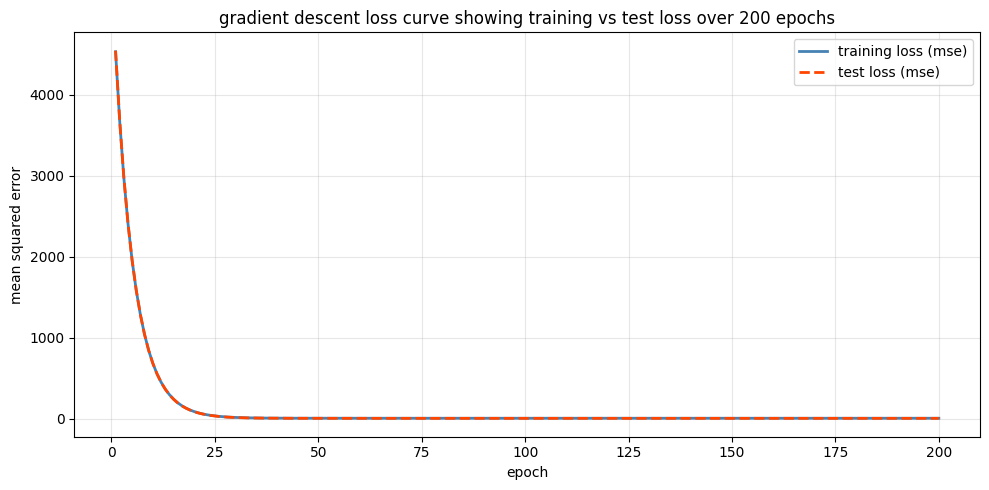

In [73]:
# loss curve plot to see if the model was actually learning over each epoch
# if both curves go down and stay close together that
# means the model is learning and not overfitting
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label='training loss (mse)', color='steelblue', linewidth=2)
plt.plot(range(1, n_epochs + 1), test_losses, label='test loss (mse)', color='orangered', linewidth=2, linestyle='--')
plt.xlabel('epoch')
plt.ylabel('mean squared error')
plt.title('gradient descent loss curve showing training vs test loss over 200 epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### decision tree regressor

In [74]:
# training a decision tree with some limits on depth to stop it from overfitting
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt_train = dt.predict(X_train_scaled)
y_pred_dt_test = dt.predict(X_test_scaled)

dt_train_r2 = r2_score(y_train, y_pred_dt_train)
dt_test_r2 = r2_score(y_test, y_pred_dt_test)
dt_train_mse = mean_squared_error(y_train, y_pred_dt_train)
dt_test_mse = mean_squared_error(y_test, y_pred_dt_test)
dt_test_mae = mean_absolute_error(y_test, y_pred_dt_test)

print('decision tree results')
print('  train r2 :', round(dt_train_r2, 4))
print('  test r2  :', round(dt_test_r2, 4))
print('  train mse:', round(dt_train_mse, 4))
print('  test mse :', round(dt_test_mse, 4))
print('  test mae :', round(dt_test_mae, 4))

decision tree results
  train r2 : 0.6589
  test r2  : 0.5524
  train mse: 5.2462
  test mse : 6.3273
  test mae : 1.511


### random forest regressor

In [75]:
# random forest trains many decision trees and averages
# their outputs which usually gives better results
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf_train = rf.predict(X_train_scaled)
y_pred_rf_test = rf.predict(X_test_scaled)

rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_test_r2 = r2_score(y_test, y_pred_rf_test)
rf_train_mse = mean_squared_error(y_train, y_pred_rf_train)
rf_test_mse = mean_squared_error(y_test, y_pred_rf_test)
rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test)

print('random forest results')
print('  train r2 :', round(rf_train_r2, 4))
print('  test r2  :', round(rf_test_r2, 4))
print('  train mse:', round(rf_train_mse, 4))
print('  test mse :', round(rf_test_mse, 4))
print('  test mae :', round(rf_test_mae, 4))

random forest results
  train r2 : 0.7661
  test r2  : 0.6774
  train mse: 3.5971
  test mse : 4.5601
  test mae : 1.0943


## 7. comparing all three models

model comparison table:
                   Train R2  Test R2  Train MSE  Test MSE  Test MAE
Model                                                              
Linear Regression    0.7084   0.7597     4.4857    3.3964    0.5539
Decision Tree        0.6589   0.5524     5.2462    6.3273    1.5110
Random Forest        0.7661   0.6774     3.5971    4.5601    1.0943


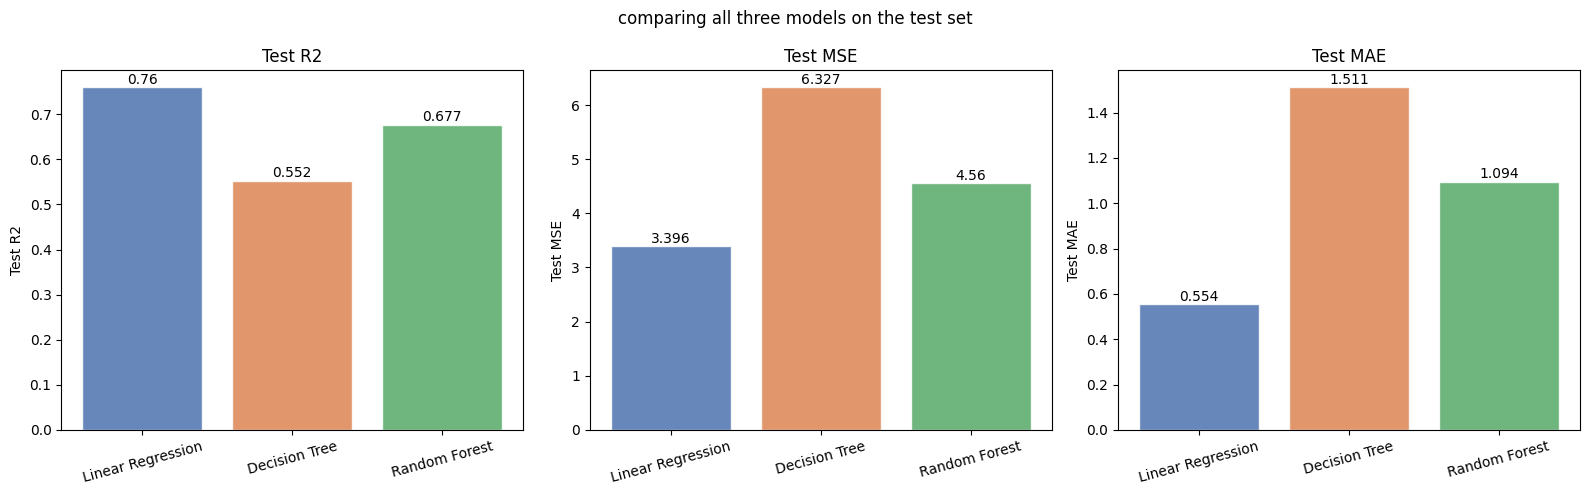

In [76]:
# putting all the results into a table so we can compare them side by side
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train R2': [lr_train_r2, dt_train_r2, rf_train_r2],
    'Test R2':  [lr_test_r2,  dt_test_r2,  rf_test_r2],
    'Train MSE': [lr_train_mse, dt_train_mse, rf_train_mse],
    'Test MSE': [lr_test_mse,  dt_test_mse,  rf_test_mse],
    'Test MAE': [lr_test_mae,  dt_test_mae,  rf_test_mae],
}).set_index('Model').round(4)

print('model comparison table:')
print(results.to_string())

# bar charts to make the comparison more visual
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Test R2', 'Test MSE', 'Test MAE']
palette = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric in zip(axes, metrics):
    vals = results[metric]
    bars = ax.bar(vals.index, vals.values, color=palette, edgecolor='white', alpha=0.85)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                str(round(val, 3)), ha='center', va='bottom', fontsize=10)

plt.suptitle('comparing all three models on the test set')
plt.tight_layout()
plt.show()

In [77]:
# picking the best model based on which one has the highest test r2 score
best_model_name = results['Test R2'].idxmax()
print('best performing model:', best_model_name)
print('test r2 score:', round(results.loc[best_model_name, 'Test R2'], 4))

best performing model: Linear Regression
test r2 score: 0.7597


## 8. scatter plot showing the regression line through the data

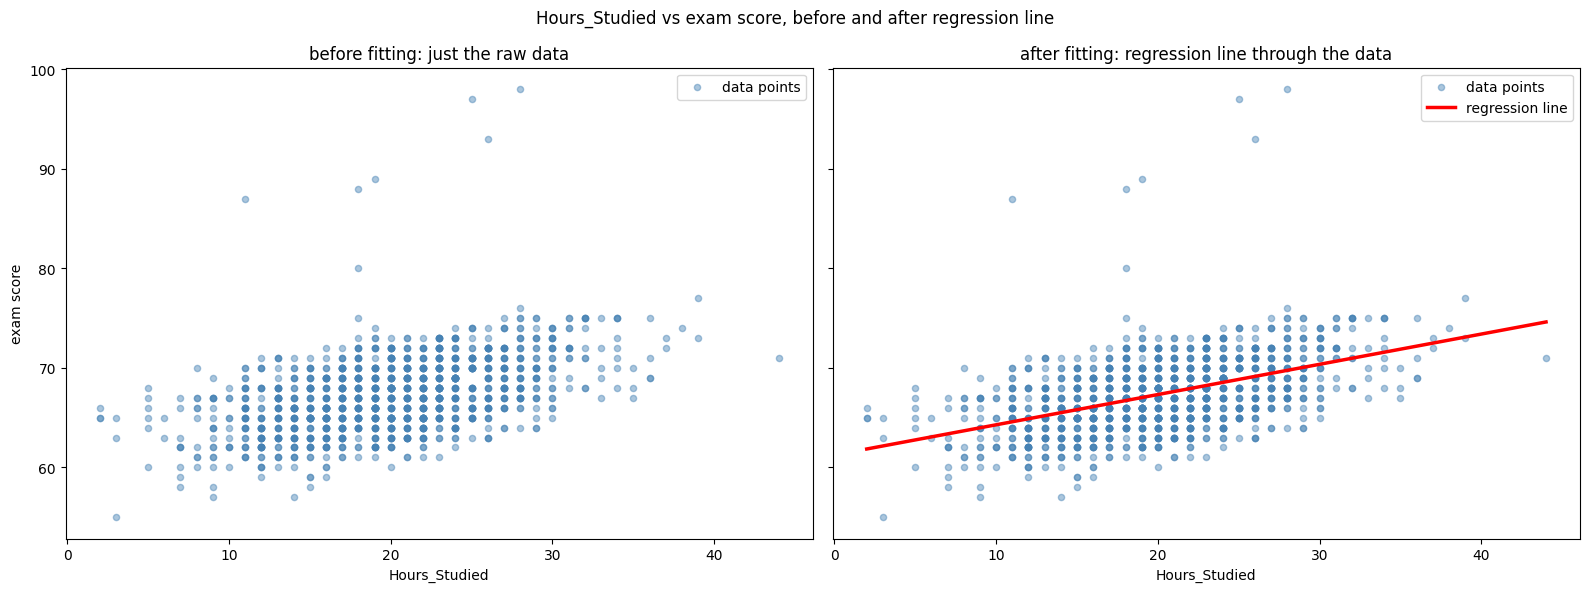

In [78]:
# using hours studied as the feature for this plot since it is usually
# one of the strongest predictors showing the data before and after
# fitting the regression line so we can see the difference

VISUAL_FEATURE = 'Hours_Studied' if 'Hours_Studied' in X.columns else X.columns[0]

x_vis = X_test[VISUAL_FEATURE].values
y_vis = y_test.values

z_vis = np.polyfit(x_vis, y_vis, 1)
p_vis = np.poly1d(z_vis)
x_sorted = np.linspace(x_vis.min(), x_vis.max(), 200)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# left side is just the raw data points with no line
axes[0].scatter(x_vis, y_vis, alpha=0.45, s=20, color='steelblue', label='data points')
axes[0].set_title('before fitting: just the raw data')
axes[0].set_xlabel(VISUAL_FEATURE)
axes[0].set_ylabel('exam score')
axes[0].legend()

# right side shows the same data but with the regression line drawn through it
axes[1].scatter(x_vis, y_vis, alpha=0.45, s=20, color='steelblue', label='data points')
axes[1].plot(x_sorted, p_vis(x_sorted), color='red', linewidth=2.5, label='regression line')
axes[1].set_title('after fitting: regression line through the data')
axes[1].set_xlabel(VISUAL_FEATURE)
axes[1].legend()

plt.suptitle(VISUAL_FEATURE + ' vs exam score, before and after regression line')
plt.tight_layout()
plt.show()

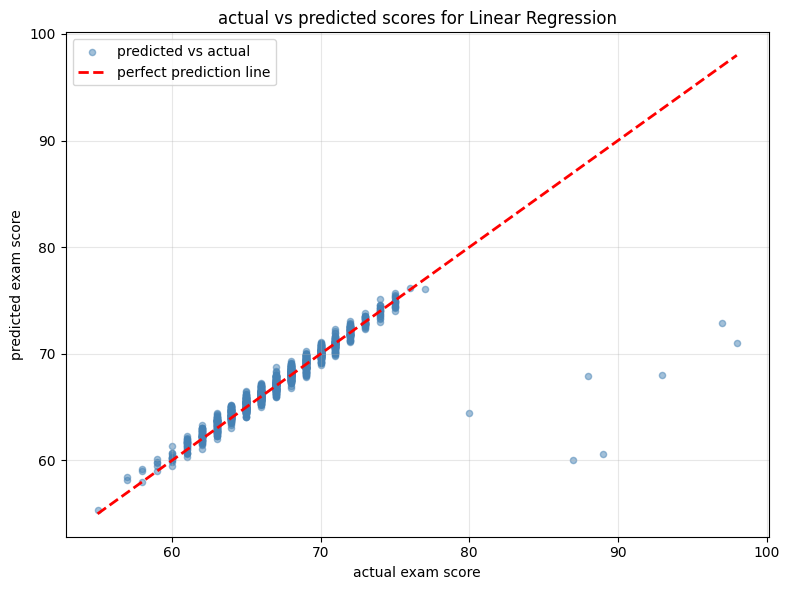

In [79]:
# also plotting actual vs predicted for the best model to see how close our predictions are
model_map = {
    'Linear Regression': (lr, y_pred_lr_test),
    'Decision Tree':     (dt, y_pred_dt_test),
    'Random Forest':     (rf, y_pred_rf_test),
}
_, best_preds = model_map[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.5, s=20, color='steelblue', label='predicted vs actual')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='perfect prediction line')
plt.xlabel('actual exam score')
plt.ylabel('predicted exam score')
plt.title('actual vs predicted scores for ' + best_model_name)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. saving the best model

In [80]:
# saving the best performing model so that I can use it later in the API
best_model_obj = model_map[best_model_name][0]

joblib.dump(best_model_obj, 'models/best_model.pkl')

# saving the feature names so the api knows what order to expect the inputs in
with open('models/feature_names.json', 'w') as f:
    json.dump(list(X.columns), f)

# saving some metadata about which model was chosen and how it performed
metadata = {
    'best_model': best_model_name,
    'test_r2': float(results.loc[best_model_name, 'Test R2']),
    'test_mse': float(results.loc[best_model_name, 'Test MSE']),
    'test_mae': float(results.loc[best_model_name, 'Test MAE']),
    'features': list(X.columns),
    'target': 'Exam_Score'
}
with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('best model saved:', best_model_name)
print('saved files: models/best_model.pkl, models/scaler.pkl, models/feature_names.json, models/model_metadata.json')
print('test r2:', round(metadata['test_r2'], 4))
print('test mse:', round(metadata['test_mse'], 4))
print('test mae:', round(metadata['test_mae'], 4))

best model saved: Linear Regression
saved files: models/best_model.pkl, models/scaler.pkl, models/feature_names.json, models/model_metadata.json
test r2: 0.7597
test mse: 3.3964
test mae: 0.5539


## 10. making a prediction on one row from the test dataset

this section takes a single real row from the test set and runs it through the full prediction pipeline using the saved model and scaler

In [81]:
# loading the saved model and scaler back in to test the full prediction pipeline
loaded_model = joblib.load('models/best_model.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')

with open('models/feature_names.json') as f:
    feature_names = json.load(f)

# grabbing the first row from the test set as our sample
# this is a real student record that the model never saw during training
sample_row = X_test.iloc[[0]]
actual_score = y_test.iloc[0]

print('input features for this student:')
print(sample_row.to_string())
print()

# scaling the row using the same scaler we used on the training data
sample_scaled = loaded_scaler.transform(sample_row[feature_names])

# running the prediction
predicted_score = loaded_model.predict(sample_scaled)[0]

print('actual exam score   :', round(float(actual_score), 2))
print('predicted exam score:', round(float(predicted_score), 2))
print('difference          :', round(abs(float(actual_score) - float(predicted_score)), 2))
print('model used          :', best_model_name)

input features for this student:
     Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  Extracurricular_Activities  Previous_Scores  Internet_Access  Tutoring_Sessions  Family_Income  Teacher_Quality  Peer_Influence  Physical_Activity  Learning_Disabilities  Parental_Education_Level  Distance_from_Home
743             20          71                     1                    0                           0               87                1                  1              1              1.0               0                  5                      0                       0.0                 0.0

actual exam score   : 65.0
predicted exam score: 64.04
difference          : 0.96
model used          : Linear Regression
